# 04_概率分布-伯努利分布

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


哈喽，咱们今天聊聊伯努利分布\~

### 什么是伯努利分布？

伯努利分布是概率论和统计学中一个非常基础的离散概率分布。

伯努利分布描述了单次实验中只有两种可能结果的情形，通常这两种结果是“成功”和“失败”，也可以是“是”和“否”或“0”和“1”。

伯努利分布适用于所有可能的二项式实验（即每次实验只有两种可能结果）。

一个很简单的例子：

当你正在掷一枚硬币的时候，每次掷硬币只有两种可能结果：正面朝上（成功，记为1）或反面朝上（失败，记为0）。每次掷硬币的结果独立于其他次掷硬币的结果，且每次掷硬币成功的概率相同。那么这个过程就符合伯努利分布。

### 伯努利分布本质

伯努利分布的本质是单次二项选择实验的结果的概率分布。

它是一个离散的概率分布，定义了成功与失败之间的概率关系。在这个分布中，某一事件发生的概率被定义为 $p$，而事件未发生的概率为 $1 - p$。

#### 伯努利分布的特点

- **只有两种可能结果：** 每次试验只有“成功”和“失败”两种结果。
- **固定的成功概率：** 每次试验的成功概率 $p$是固定的。
- **独立性：** 每次试验的结果独立于其他试验。
- **离散性：** 伯努利分布是离散的概率分布，输出只有两个值：0或1。

#### 现实生活中的伯努利分布例子

- **硬币投掷：** 每次投掷硬币的结果是“正面”或“反面”。
- **电子设备的开关：** 电子设备可能开或关。
- **是否通过考试：** 某人可能通过考试（成功）或者没有通过（失败）。

## 公式推导

### 伯努利分布的概率质量函数

伯努利分布的概率质量函数（PMF）描述了一个单一试验成功（或者失败）的概率。

对于一个伯努利试验，其概率质量函数表示：


$$
P(X = x) = p^x(1-p)^{1-x}, \quad x \in \{0, 1\}
$$


其中：

$X$是表示实验结果的随机变量，它可以取值 0（失败）或者 1（成功）。

$p$是成功的概率， $0 \leq p \leq 1$。

$(1-p)$是失败的概率。

### 公式的推导

伯努利分布来源于基本的概率论。如果我们进行一次试验（如硬币投掷），则该试验的成功概率为 $p$，而失败的概率为 $1-p$。

1. **成功的概率**：成功的概率是 $p$，即 $P(X = 1) = p$。
2. **失败的概率**：失败的概率是 $1 - p$，即 $P(X = 0) = 1 - p$。

所以，伯努利分布的公式就由以下推导而来：

- 如果 $X = 1$（成功），则概率为 $p$。
- 如果 $X = 0$（失败），则概率为 $1 - p$。

因此，我们得到了概率质量函数：  
$P(X = x) = p^x(1-p)^{1-x}, \quad x \in \{0, 1\}$  
这个公式可以看作是根据 $x$的值来决定是成功还是失败的概率。

### 伯努利分布的期望和方差

- **期望值（均值）：**伯努利分布的期望值（均值）是试验成功的概率 $p$：  
$E(X) = p$
- **方差：**伯努利分布的方差衡量了试验结果的波动程度，其计算公式为：  
$\text{Var}(X) = p(1 - p)$

其中，期望值反映了在多次试验中的平均成功概率，方差则表明成功概率在不同实验中的变化幅度。

## 案例说明

为了方便说明问题，我们通过 Python 代码来生成伯努利分布的数据\~

首先，使用 `numpy` 库来生成伯努利分布的数据，即函数：`np.random.binomial()`。

通过 `numpy.random.binomial` 方法生成伯努利分布的数据。然后，我们将使用 `matplotlib` 进行可视化\~

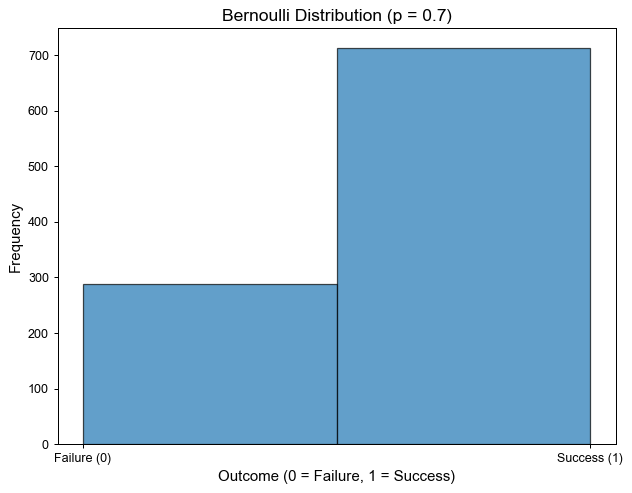

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 设置成功概率 p
p = 0.7
# 设置试验次数
n_trials = 1000

# 使用 numpy 的 binomial 函数生成伯努利分布的数据
# binomial(n, p) 中 n = 1 表示一次实验（伯努利试验）
data = np.random.binomial(1, p, n_trials)

# 可视化伯努利分布数据
plt.figure(figsize=(8, 6))
plt.hist(data, bins=2, edgecolor='black', alpha=0.7)
plt.title('Bernoulli Distribution (p = 0.7)', fontsize=14)
plt.xlabel('Outcome (0 = Failure, 1 = Success)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks([0, 1], ['Failure (0)', 'Success (1)'])
plt.show()

1. `np.random.binomial(1, p, n_trials)`：使用 `binomial` 函数生成伯努利分布数据，`1` 表示进行单次实验，`p` 是成功的概率，`n_trials` 是试验的次数。
2. `plt.hist(data, bins=2, edgecolor='black', alpha=0.7)`：使用 `matplotlib` 绘制伯努利分布的数据直方图，`bins=2` 表示数据只有两个值（0 和 1）。
3. `plt.xticks([0, 1], ['Failure (0)', 'Success (1)'])`：将x轴的标签设置为“失败”和“成功”。

![原文参考图，当前结果见代码输出](attachments/img_001.png)

### 机器学习算法应用：二分类问题

在机器学习中，伯努利分布常用于建模二分类问题的输出。我们可以使用伯努利分布来描述类别标签 $y \in \{0, 1\}$ 的概率分布，且该分布通常会依赖于一个模型的输出概率。在二分类任务中，模型的输出通常是一个概率值，表示某一类别发生的概率。

### Logistic回归中的伯努利分布

在逻辑回归（Logistic Regression）中，伯努利分布用来描述数据点属于某一类别的概率。逻辑回归模型的输出是一个介于0和1之间的概率值，表示某一类别的发生概率。我们假设输出的类别标签是 $y \in \{0, 1\}$，并且给定输入特征 $x$时，类别为1的概率为 $\hat{p}$。

逻辑回归模型的输出是通过sigmoid函数计算的，公式如下：


$$
\hat{p} = \sigma(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}
$$


其中：

- $w$是特征权重，
- $x$是输入特征，
- $b$是偏置项，
- $\sigma(z)$是sigmoid函数。

逻辑回归模型的损失函数通常使用交叉熵（cross-entropy），它与伯努利分布密切相关。交叉熵损失函数的形式为：


$$
\text{Loss}(y, \hat{y}) = -\left[y \log(\hat{y}) + (1 - y) \log(1 - \hat{y})\right]
$$


其中 $y$是真实标签，$\hat{y}$是模型预测的概率。这个损失函数是在伯努利分布的背景下定义的，表示真实标签和模型预测之间的差距。

### 伯努利分布与最大似然估计

最大似然估计（Maximum Likelihood Estimation, MLE）是一种用于估计模型参数的常用方法。

在伯努利分布的情况下，MLE可以用来估计成功概率 $p$。

假设我们有 $n$次伯努利试验，每次试验的成功概率是 $p$，成功的结果记为1，失败的结果记为0。

设每次试验的结果为 $x_1, x_2, ..., x_n$，其中 $x_i \in \{0, 1\}$。

那么，在伯努利分布的框架下，似然函数 $L(p)$为：


$$
L(p) = \prod_{i=1}^{n} p^{x_i}(1 - p)^{1 - x_i}
$$


我们通常会最大化似然函数来找到最优的成功概率 $p$。为了简化计算，通常对似然函数取对数，得到对数似然函数（log-likelihood）：


$$
\log L(p) = \sum_{i=1}^{n} \left[ x_i \log(p) + (1 - x_i) \log(1 - p) \right]
$$


最大化对数似然函数即可得到最优的 $p$，该值为成功次数与总试验次数之比：


$$
\hat{p} = \frac{\sum_{i=1}^{n} x_i}{n}
$$


这个估计值 $\hat{p}$就是成功的估计概率，它是样本中成功事件的频率。

### 逻辑回归训练与伯努利分布

在逻辑回归中，我们通常会通过梯度下降法来训练模型。我们可以使用 `scikit-learn` 库来实现这一过程。

这里是一个基于伯努利分布的逻辑回归例子，应用伯努利分布和最大似然估计来进行二分类任务。

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 生成模拟的二分类数据：特征X和标签y
# 这里我们随机生成特征数据（0或1）和标签数据（0或1）
X = np.random.randint(0, 2, (1000, 2))  # 假设有两个特征
y = np.random.binomial(1, p, 1000)  # 标签是伯努利分布生成的，成功概率为p

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 训练逻辑回归模型
model = LogisticRegression()
model.fit(X_train, y_train)

# 预测并评估模型性能
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model accuracy: {accuracy * 100:.2f}%")

Model accuracy: 70.33%


1. **数据生成**：我们随机生成了一个具有两个特征的数据集 $X$，以及一个二分类标签 $y$，标签 $y$是基于伯努利分布生成的。
2. **模型训练**：使用 `LogisticRegression` 类训练逻辑回归模型，训练数据为 $X_{\text{train}}$和 $y_{\text{train}}$。
3. **评估模型**：使用 `accuracy_score` 计算模型在测试集上的准确率。

### 伯努利分布与逻辑回归的关系

在逻辑回归模型中，我们假设输出标签是基于伯努利分布生成的，而逻辑回归模型的目标就是通过最大化似然函数来学习出成功的概率 $p$。逻辑回归模型的输出是一个介于0和1之间的概率值，表示预测为类别1的概率。

当我们使用交叉熵损失函数时，实际上是在使用伯努利分布的对数似然估计来最小化损失。训练的过程就是不断调整模型参数 $w$和 $b$，使得预测的概率 $\hat{p}$与实际标签 $y$尽可能接近。

## 最后

伯努利分布是概率论中一个重要的离散分布，它描述了一个只有两个可能结果的试验（例如，成功与失败）。在许多实际问题中，伯努利分布被广泛应用于建模二分类问题，如硬币投掷、疾病诊断、市场营销等。